# SPO Baseline — SPO+ + LS Hybrid（对应原始 e2e_v5c_eq21_aligned）

本文件一一对应原始 v5c notebook：保留 Eq.(21)-aligned SOCP+TC oracle、MLP、rolling window 与评价口径，只把训练主损失替换为 SPO+ + MSE anchor hybrid。


## 1. 配置

In [1]:
from pathlib import Path

# ── 相对路径：默认 notebook 与数据文件在同一目录 ───────────────────────────
# 如果你把数据放在 ./data/ 下，只需要改成 DATA_DIR = PROJECT_ROOT / "data"
PROJECT_ROOT = Path.cwd()
DATA_DIR     = PROJECT_ROOT
OUT_DIR      = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH   = DATA_DIR / 'hs300_factor_data_filled.parquet'
PANEL_PATH = DATA_DIR / 'factor_panel_v2_processed.parquet'
IC_PATH    = DATA_DIR / '03v3_ic_summary.csv'

# ── 因子筛选 ─────────────────────────────────────────────────────────────
IC_TSTAT_THRESHOLD = 2.0
MIN_COVERAGE       = 0.70
FWD_RET_COVERAGE   = 0.80

# ── 模型与训练参数（保持原文件口径）───────────────────────────────────────
HIDDEN_DIM = 32
SEED       = 42
N_WARM     = 10
N_E2E      = 60
LR_MSE     = 1e-3
LR_E2E     = 1e-4
GRAD_CLIP  = 1.0
BATCH_SIZE = 8

# ── 风险偏好与交易成本参数（保持 v5c / Eq.21 口径）────────────────────────
LAMBDA      = 1.0
LAMBDA_LIST = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
GAMMA       = 0.003
ZETA_TRAIN  = 10.0
EPS_TC      = 1e-6
ALPHA_IC    = 0.05
MAX_W_FRAC  = 10
TC_RATE     = GAMMA
TRAIN_WINDOW = 36
STEP_SIZE    = 3

# ── SPO baseline 开关 ─────────────────────────────────────────────────────
SPO_RUN_NAME   = 'spo_plus_ls_hybrid_v5c_eq21_aligned'
SPO_LOSS_LABEL = 'SPO+ + LS hybrid loss'
RUN_LAMBDA_SWEEP = True
HYBRID_LS_WEIGHT = 1.0

print("=" * 72)
print(f"{SPO_RUN_NAME}")
print("=" * 72)
print(f"DATA_DIR     = {DATA_DIR}")
print(f"PANEL_PATH   = {PANEL_PATH}")
print(f"IC_PATH      = {IC_PATH}")
print(f"OUT_DIR      = {OUT_DIR}")
print(f"LOSS         = {SPO_LOSS_LABEL}")
print(f"N_WARM={N_WARM}, N_E2E={N_E2E}, BATCH_SIZE={BATCH_SIZE}")


spo_plus_ls_hybrid_v5c_eq21_aligned
DATA_DIR     = c:\Users\lamda\Desktop\SPO
PANEL_PATH   = c:\Users\lamda\Desktop\SPO\factor_panel_v2_processed.parquet
IC_PATH      = c:\Users\lamda\Desktop\SPO\03v3_ic_summary.csv
OUT_DIR      = c:\Users\lamda\Desktop\SPO\outputs
LOSS         = SPO+ + LS hybrid loss
N_WARM=10, N_E2E=60, BATCH_SIZE=8


## 2. 导入与数据加载

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings, time
from collections import Counter
from scipy.optimize import brentq
warnings.filterwarnings('ignore')

import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F

torch.manual_seed(SEED); np.random.seed(SEED)
plt.rcParams['font.sans-serif'] = ['SimHei','Arial Unicode MS','DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


def date_as_date(x):
    return pd.Timestamp(x).date()

def date_as_ym(x):
    return pd.Timestamp(x).strftime('%y-%m')

def date_as_Ym(x):
    return pd.Timestamp(x).strftime('%Y-%m')

panel = pd.read_parquet(PANEL_PATH)
panel['date'] = pd.to_datetime(panel['date'])
ic_df = pd.read_csv(IC_PATH, index_col=0)
if 'Sig(|t|>2)' in ic_df.columns:    sig_mask = ic_df['Sig(|t|>2)']
elif 't_stat' in ic_df.columns:       sig_mask = ic_df['t_stat'].abs() > IC_TSTAT_THRESHOLD
else: raise ValueError("IC 文件需含 t_stat 或 Sig(|t|>2) 列")
SIG_FACTORS = list(ic_df[sig_mask].index); N_FEATURES = len(SIG_FACTORS)
print(f"Factor panel: {panel.shape}  ({panel['date'].nunique()} months)")
print(f"显著因子 ({N_FEATURES} 个): {SIG_FACTORS}")
assert N_FEATURES >= 2

Factor panel: (21760, 105)  (68 months)
显著因子 (10 个): ['F91_ocf_ni', 'F97_accruals', 'F80_ocf_mv', 'F74_cfp', 'F55_holding_adj', 'F81_size', 'F34_vol_of_vol', 'F88_cash_roe', 'F41_turn_std', 'F30_range_vol']


## 3. 股票池 & 特征

In [3]:
all_dates = sorted(panel['date'].unique())
def get_valid_stocks(df, factors):
    return set(df.dropna(subset=factors + ['fwd_ret'])['ts_code'].unique())
month_valid = {d: get_valid_stocks(panel[panel['date']==d], SIG_FACTORS) for d in all_dates}
stock_cnt = Counter(s for v in month_valid.values() for s in v)
universe  = sorted(s for s,c in stock_cnt.items() if c/len(all_dates) >= MIN_COVERAGE)
N = len(universe); MAX_W = MAX_W_FRAC / N

panel_u = (panel[panel['ts_code'].isin(universe)].sort_values(['date','ts_code']).reset_index(drop=True))
for col in SIG_FACTORS:
    panel_u[col] = panel_u.groupby('date')[col].transform(
        lambda x: x.fillna(0 if x.isna().all() else x.mean()))
panel_u['fwd_ret'] = panel_u.groupby('date')['fwd_ret'].transform(
    lambda x: x.fillna(x.median() if not x.isna().all() else 0))
def cross_sec_zscore(arr):
    mu = arr.mean(0,keepdims=True); sig = np.maximum(arr.std(0,keepdims=True),1e-8)
    return np.nan_to_num((arr-mu)/sig).astype('float32')
fwd_cov = panel_u.groupby('date')['fwd_ret'].apply(lambda x: x.notna().mean())
dates_valid = [d for d in sorted(panel_u['date'].unique()) if fwd_cov.get(d,0) >= FWD_RET_COVERAGE]
X_tensors, y_tensors = [], []
for d in dates_valid:
    sub = panel_u[panel_u['date']==d].sort_values('ts_code')
    X_tensors.append(torch.tensor(cross_sec_zscore(sub[SIG_FACTORS].values)))
    y_tensors.append(torch.tensor(sub['fwd_ret'].values.astype('float32')))
T = len(X_tensors)
print(f"股票池: {N} 只   max_w = {MAX_W_FRAC}/N = {MAX_W:.4f}  有效月份: {T}")

股票池: 252 只   max_w = 10/N = 0.0397  有效月份: 68


## 4. 滚动窗口

In [4]:
rolling_windows = []
start = 0
while start + TRAIN_WINDOW + STEP_SIZE <= T:
    rolling_windows.append({
        'train_start': start,           'train_end': start + TRAIN_WINDOW,
        'test_start' : start + TRAIN_WINDOW,
        'test_end'   : min(start + TRAIN_WINDOW + STEP_SIZE, T),
    })
    start += STEP_SIZE

assert rolling_windows, f"数据不足，T={T}，需至少 {TRAIN_WINDOW + STEP_SIZE} 月"
fw, lw = rolling_windows[0], rolling_windows[-1]
n_test_total = sum(w['test_end'] - w['test_start'] for w in rolling_windows)

print(f"滚动窗口: {len(rolling_windows)} 个  累计测试月: {n_test_total}")
print(f"首: [{pd.Timestamp(dates_valid[fw['train_start']]).date()}~{pd.Timestamp(dates_valid[fw['train_end']-1]).date()}] → [{pd.Timestamp(dates_valid[fw['test_start']]).date()}~{pd.Timestamp(dates_valid[fw['test_end']-1]).date()}]")
print(f"末: 测试 [{pd.Timestamp(dates_valid[lw['test_start']]).date()}~{pd.Timestamp(dates_valid[lw['test_end']-1]).date()}]")


滚动窗口: 10 个  累计测试月: 30
首: [2020-04-30~2023-03-31] → [2023-04-28~2023-06-30]
末: 测试 [2025-07-31~2025-09-30]


## 5. 可微 SOCP + TC 层（v5c）

内层与论文 Eq.(21) 对齐，只是在实现上把

\[
\|w-w_{t-1}\|_1
\]

平滑为

\[
\sum_i \sqrt{(w_i-w_{i,t-1})^2+\varepsilon_{\text{tc}}}.
\]

因此训练时优化的是：

\[
\min_w\;
-\mu^\top w
+\frac{\gamma}{2}\sum_i \sqrt{(w_i-w_{i,t-1})^2+\varepsilon_{\text{tc}}}
+\lambda\sqrt{w^\top Dw}
+\frac{\zeta}{2}\|w\|^2
\]

subject to \(w\ge 0,\; \mathbf 1^\top w=1,\; w\le 10/N\).


In [5]:
import numpy as np, torch, torch.nn as nn
from scipy.optimize import brentq

def smooth_l1_value_np(delta, eps):
    return np.sqrt(delta**2 + eps).sum()

def smooth_l1_grad_vec(delta, eps):
    return delta / np.sqrt(delta**2 + eps)

def smooth_l1_hess_diag(delta, eps):
    return eps / (delta**2 + eps)**1.5

def smooth_l1_value_torch(delta, eps):
    return torch.sqrt(delta.pow(2) + eps).sum()

def turnover_l1_np(w, w_prev):
    return np.abs(w - w_prev).sum()

def turnover_l1_torch(w, w_prev):
    return (w - w_prev).abs().sum()


def solve_socp_tc(mu_np, var_np, w_prev_np, lambda_, gamma, max_w, zeta,
                  eps_tc=1e-4, max_outer=30, max_inner=50, tol=1e-10):
    """
    Solve the smoothed Eq.(21) inner problem under diagonal covariance:

        min_w  -mu^T w
               + 0.5*gamma*sum_i sqrt((w_i-wprev_i)^2 + eps_tc)
               + lambda*sqrt(w^T D w)
               + 0.5*zeta*||w||^2
        s.t.   sum(w)=1, 0<=w<=max_w

    Strategy:
      - outer loop linearizes the TC term at current iterate
      - inner loop solves the resulting diagonal-risk SOCP by fixed point on P = sqrt(w^T D w)

    This stays close to the notebook's existing SOCP design and keeps the implementation stable.
    """
    n = len(mu_np)

    # Initial point: solve the zeta-smoothed LP, centered around mu only.
    z0 = max(zeta, 1e-6)
    def init_budget(nu):
        return np.clip((mu_np - nu) / z0, 0, max_w).sum() - 1.0

    try:
        nu0 = brentq(init_budget, mu_np.min() - max_w * z0 - 1.0, mu_np.max() + 1.0,
                     xtol=1e-12, maxiter=300)
        w = np.clip((mu_np - nu0) / z0, 0, max_w)
        s = w.sum()
        w = w / s if s > 1e-12 else np.ones(n) / n
    except Exception:
        w = np.ones(n) / n

    P = max(np.sqrt((w**2 * var_np).sum()), 1e-8)

    for _ in range(max_outer):
        delta = w - w_prev_np
        tc_grad = 0.5 * gamma * smooth_l1_grad_vec(delta, eps_tc)
        mu_eff = mu_np - tc_grad

        w_new, P_new = w.copy(), P
        for _ in range(max_inner):
            eff_z = lambda_ * var_np / P_new + zeta

            def budget(nu):
                return np.clip((mu_eff - nu) / eff_z, 0, max_w).sum() - 1.0

            nu_lo = (mu_eff - eff_z * max_w).max() - 1.0
            nu_hi = mu_eff.max() + 1.0

            try:
                nu = brentq(budget, nu_lo, nu_hi, xtol=1e-12, maxiter=400)
                w_try = np.clip((mu_eff - nu) / eff_z, 0, max_w)
                s = w_try.sum()
                w_try = w_try / s if s > 1e-12 else np.ones(n) / n
            except Exception:
                break

            P_try = max(np.sqrt((w_try**2 * var_np).sum()), 1e-8)
            if abs(P_try - P_new) < tol:
                w_new, P_new = w_try, P_try
                break
            w_new, P_new = w_try, P_try

        if np.max(np.abs(w_new - w)) < tol:
            w, P = w_new, P_new
            break
        w, P = w_new, P_new

    return w, P


class SOCPTCFunction(torch.autograd.Function):
    """
    Forward :
        solve_socp_tc

    Backward :
        implicit differentiation on the free set F.

    For free variables, the diagonal part of the Hessian is

        h_i = lambda * var_i / P
              + zeta
              + 0.5 * gamma * eps_tc / (Delta_i^2 + eps_tc)^(3/2)

    together with the usual rank-1 correction from the sqrt(w^T D w) term.
    """

    @staticmethod
    def forward(ctx, mu, var, w_prev, lambda_, gamma, max_w, zeta, eps_tc):
        n        = mu.shape[0]
        mu_np    = mu.detach().cpu().numpy().astype(np.float64)
        var_np   = var.detach().cpu().numpy().astype(np.float64)
        wprev_np = w_prev.detach().cpu().numpy().astype(np.float64)

        w_np, P = solve_socp_tc(mu_np, var_np, wprev_np, lambda_, gamma, max_w, zeta, eps_tc=eps_tc)

        eps_free = 1e-6
        free = (w_np > eps_free) & (w_np < max_w - eps_free)

        ctx.save_for_backward(torch.tensor(w_np, dtype=mu.dtype),
                              torch.tensor(var_np, dtype=mu.dtype),
                              torch.tensor(wprev_np, dtype=mu.dtype))
        ctx.P = P
        ctx.lambda_ = lambda_
        ctx.gamma = gamma
        ctx.zeta = zeta
        ctx.eps_tc = eps_tc
        ctx.max_w = max_w
        ctx.free = free
        ctx.n = n
        return torch.tensor(w_np, dtype=mu.dtype)

    @staticmethod
    def backward(ctx, grad_output):
        w_star, var_t, w_prev_t = ctx.saved_tensors
        P       = ctx.P
        lam     = ctx.lambda_
        gam     = ctx.gamma
        zeta    = ctx.zeta
        eps_tc  = ctx.eps_tc
        free    = ctx.free
        n       = ctx.n

        n_free = int(free.sum())
        if n_free == 0:
            return (torch.zeros(n, dtype=grad_output.dtype),) + (None,) * 7

        free_idx = np.where(free)[0]
        w_F      = w_star.detach().cpu().numpy()[free_idx]
        var_F    = var_t.detach().cpu().numpy()[free_idx]
        wprev_F  = w_prev_t.detach().cpu().numpy()[free_idx]
        delta_F  = w_F - wprev_F

        tc_hess  = 0.5 * gam * smooth_l1_hess_diag(delta_F, eps_tc)
        H_diag   = lam * var_F / P + zeta + tc_hess
        alpha_F  = var_F * w_F / P

        K = np.zeros((n_free + 1, n_free + 1))
        K[:n_free, :n_free] = np.diag(H_diag) - (lam / P) * np.outer(alpha_F, alpha_F)
        K[:n_free,  n_free] = 1.0
        K[n_free, :n_free]  = 1.0

        try:
            K_inv = np.linalg.solve(K, np.eye(n_free + 1))
        except Exception:
            K_inv = np.linalg.lstsq(K, np.eye(n_free + 1), rcond=None)[0]

        dw_dmu = K_inv[:n_free, :n_free]
        grad_np = grad_output.detach().cpu().numpy().astype(np.float64)

        grad_mu = np.zeros(n, dtype=np.float64)
        grad_mu[free_idx] = dw_dmu @ grad_np[free_idx]

        # We keep w_prev as a state input in this notebook and do not backpropagate through time.
        # So gradients wrt w_prev are intentionally set to zero here for stability.
        grad_wprev = torch.zeros(n, dtype=grad_output.dtype)

        return (torch.tensor(grad_mu, dtype=grad_output.dtype),
                None,
                grad_wprev,
                None, None, None, None, None)


class DifferentiableSOCPTC(nn.Module):
    def __init__(self, max_w, lambda_, gamma, zeta, eps_tc=1e-4):
        super().__init__()
        self.max_w = max_w
        self.lambda_ = lambda_
        self.gamma = gamma
        self.zeta = zeta
        self.eps_tc = eps_tc

    def forward(self, mu, var, w_prev):
        return SOCPTCFunction.apply(mu, var, w_prev,
                                    self.lambda_, self.gamma,
                                    self.max_w, self.zeta, self.eps_tc)


print("=== Gradient-flow sanity check (v5c: risk + TC) ===")
torch.manual_seed(0)
_mlp   = nn.Sequential(nn.Linear(N_FEATURES, 32), nn.ReLU(), nn.Linear(32, 1))
_X, _y = X_tensors[10], y_tensors[10]
_var_np = np.stack([y_tensors[i].numpy() for i in range(20)]).var(axis=0)
_var_np = np.maximum(_var_np, 1e-6).astype('float32')
_var_t  = torch.tensor(_var_np)
_wprev  = torch.ones(N) / N
_layer  = DifferentiableSOCPTC(max_w=MAX_W, lambda_=LAMBDA, gamma=GAMMA,
                               zeta=ZETA_TRAIN, eps_tc=EPS_TC)

_mu = _mlp(_X).squeeze(-1)
_w  = _layer(_mu, _var_t, _wprev)
loss = -(_w * _y).sum()
loss.backward()

norms = [p.grad.norm().item() if p.grad is not None else 0.0 for p in _mlp.parameters()]
_free = int(((_w.detach() > 1e-6) & (_w.detach() < MAX_W - 1e-6)).sum())
print(f"free_vars = {_free}/{N}   sum(w) = {_w.sum().item():.6f}")
print(f"grad_norms = {[f'{v:.2e}' for v in norms]}")
print("OK" if all(v > 0 for v in norms) else "WARNING: some gradients are zero")

del _mlp, _X, _y, _var_np, _var_t, _wprev, _layer, _mu, _w, loss


=== Gradient-flow sanity check (v5c: risk + TC) ===
free_vars = 135/252   sum(w) = 1.000000
grad_norms = ['4.21e-01', '8.74e-02', '5.46e-01', '1.49e-08']
OK


## 6. 模型定义

In [6]:
class CrossSectionalMLP(nn.Module):
    def __init__(self, n_features=N_FEATURES, hidden=HIDDEN_DIM):
        super().__init__()
        h2 = max(hidden//2, 4)
        self.net = nn.Sequential(
            nn.LayerNorm(n_features),
            nn.Linear(n_features,hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(0.05),
            nn.Linear(hidden,h2),         nn.BatchNorm1d(h2),     nn.ReLU(), nn.Dropout(0.05),
            nn.Linear(h2, 1))
    def forward(self, X): return self.net(X).squeeze(-1)

_tmp = CrossSectionalMLP()
print(f"模型参数: {sum(p.numel() for p in _tmp.parameters())}"); del _tmp

模型参数: 1013


## 7. 训练函数（SPO baseline：SPO+ + LS hybrid loss）


In [7]:
def compute_var_vec(y_tr_list):
    mat = np.stack([y.numpy() for y in y_tr_list])
    return np.maximum(mat.var(axis=0), 1e-6).astype('float32')


def ic_aux_loss(mu_hat, y_true, alpha=ALPHA_IC):
    if alpha <= 0:
        return torch.tensor(0.0, dtype=mu_hat.dtype)
    mu_c = mu_hat - mu_hat.mean()
    y_c  = (y_true - y_true.mean()).detach()
    ic_t = (mu_c * y_c).sum() / (mu_c.norm() * y_c.norm() + 1e-8)
    return -alpha * ic_t


def safe_socp_tc(layer, mu, var_t, w_prev):
    try:
        return layer(mu, var_t, w_prev)
    except Exception:
        return torch.ones_like(mu) / mu.numel() + 0.0 * mu


def portfolio_cost_tc_from_return(r_vec, w, var_t, w_prev, lambda_, gamma):
    """Eq.(21)-aligned cost: -r^T w + lambda*std + 0.5*gamma*smooth_L1(w-w_prev)."""
    port_ret = (w * r_vec).sum()
    port_std = torch.sqrt((w.pow(2) * var_t).sum() + 1e-8)
    tc_term  = smooth_l1_value_torch(w - w_prev, EPS_TC)
    return -port_ret + lambda_ * port_std + 0.5 * gamma * tc_term


def spo_plus_hybrid_loss_t(mu_hat, y_true, var_t, w_prev, lambda_, gamma, socp_layer):
    """SPO+ modified-return oracle + MSE anchor under the same v5c risk+TC oracle."""
    r_mix = 2.0 * mu_hat - y_true.detach()
    w_mix = safe_socp_tc(socp_layer, r_mix, var_t, w_prev)
    with torch.no_grad():
        try:
            w_true = socp_layer(y_true.detach(), var_t, w_prev).detach()
        except Exception:
            w_true = (torch.ones_like(y_true) / y_true.numel()).detach()

    cost_mix = portfolio_cost_tc_from_return(y_true, w_mix, var_t, w_prev, lambda_, gamma)
    cost_true = portfolio_cost_tc_from_return(y_true, w_true, var_t, w_prev, lambda_, gamma).detach()
    spo_plus_shifted = cost_mix - cost_true
    ls_anchor = F.mse_loss(mu_hat, y_true)
    return spo_plus_shifted + HYBRID_LS_WEIGHT * ls_anchor, w_mix


def train_spo_v5c(model, X_tr, y_tr, var_vec, lambda_, gamma,
                  n_warm, n_spo, lr_mse, lr_spo,
                  grad_clip=GRAD_CLIP, batch_size=BATCH_SIZE):
    T_tr = len(X_tr)
    var_t = torch.tensor(var_vec, dtype=torch.float32)
    socp_train = DifferentiableSOCPTC(max_w=MAX_W, lambda_=lambda_, gamma=gamma,
                                      zeta=ZETA_TRAIN, eps_tc=EPS_TC)
    hist = {'mse': [], 'spo': [], 'free_vars': []}

    opt = optim.Adam(model.parameters(), lr=lr_mse)
    for ep in range(n_warm):
        model.train(); ep_loss = 0.0; n_batches = 0
        for bs in range(0, T_tr, batch_size):
            be = min(bs + batch_size, T_tr)
            opt.zero_grad()
            bl = sum(F.mse_loss(model(X_tr[t]), y_tr[t]) for t in range(bs, be))
            avg = bl / (be - bs)
            avg.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += avg.item(); n_batches += 1
        hist['mse'].append(ep_loss / max(n_batches, 1))

    opt = optim.Adam(model.parameters(), lr=lr_spo)
    for ep in range(n_spo):
        model.train(); ep_loss = 0.0; n_batches = 0; ep_free = 0
        w_prev_ep = (torch.ones(N) / N).detach()

        for bs in range(0, T_tr, batch_size):
            be = min(bs + batch_size, T_tr)
            opt.zero_grad()
            bl = torch.tensor(0.0)

            for t in range(bs, be):
                mu_hat = model(X_tr[t])
                loss_t, w_diag = spo_plus_hybrid_loss_t(mu_hat, y_tr[t], var_t, w_prev_ep,
                                                        lambda_, gamma, socp_train)
                bl = bl + loss_t + ic_aux_loss(mu_hat, y_tr[t])

                with torch.no_grad():
                    _w = w_diag.detach()
                    ep_free += int(((_w > 1e-6) & (_w < MAX_W - 1e-6)).sum())
                w_prev_ep = w_diag.detach()

            avg = bl / (be - bs)
            avg.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += avg.item(); n_batches += 1

        hist['spo'].append(ep_loss / max(n_batches, 1))
        hist['free_vars'].append(ep_free / max(T_tr, 1))
    return hist


def train_mse_v5c(model, X_tr, y_tr, n_epochs, lr,
                  grad_clip=GRAD_CLIP, batch_size=BATCH_SIZE):
    T_tr = len(X_tr); hist = []
    opt = optim.Adam(model.parameters(), lr=lr)
    for ep in range(n_epochs):
        model.train(); ep_loss = 0.0; n_batches = 0
        for bs in range(0, T_tr, batch_size):
            be = min(bs + batch_size, T_tr)
            opt.zero_grad()
            bl = sum(F.mse_loss(model(X_tr[t]), y_tr[t]) for t in range(bs, be))
            avg = bl / (be - bs)
            avg.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += avg.item(); n_batches += 1
        hist.append(ep_loss / max(n_batches, 1))
    return hist

print("Training functions v5c ready")
print(f"  SPO loss: {SPO_LOSS_LABEL}; HYBRID_LS_WEIGHT={HYBRID_LS_WEIGHT}")
print(f"  Inner/outer oracle keep gamma={GAMMA}, lambda={LAMBDA}; no loss-constraint mismatch.")


Training functions v5c ready
  SPO loss: SPO+ + LS hybrid loss; HYBRID_LS_WEIGHT=1.0
  Inner/outer oracle keep gamma=0.003, lambda=1.0; no loss-constraint mismatch.


## 8. 滚动运行器（SPO baseline）


In [8]:
def run_rolling_v5c(mode, lambda_=LAMBDA, gamma=GAMMA):
    assert mode in ('spo', 'mse')
    res = {'returns': [], 'weights': [], 'dates': [], 'bench': [],
           'free_vars': [], 'loss_curves': []}
    w_prev = (torch.ones(N) / N).detach()
    t0 = time.time()

    for idx, win in enumerate(rolling_windows):
        ts, te = win['train_start'], win['train_end']
        vs, ve = win['test_start'],  win['test_end']
        X_tr = [X_tensors[i] for i in range(ts, te)]
        y_tr = [y_tensors[i] for i in range(ts, te)]

        var_vec = compute_var_vec(y_tr)
        var_t = torch.tensor(var_vec, dtype=torch.float32)

        torch.manual_seed(SEED + idx * 37)
        model_w = CrossSectionalMLP()

        if mode == 'spo':
            hist = train_spo_v5c(model_w, X_tr, y_tr, var_vec, lambda_, gamma,
                                 N_WARM, N_E2E, LR_MSE, LR_E2E)
            final_loss = hist['spo'][-1] if hist['spo'] else float('nan')
            avg_train_free = hist['free_vars'][-1] if hist['free_vars'] else 0.0
            res['loss_curves'].append(hist['spo'])
        else:
            hist = train_mse_v5c(model_w, X_tr, y_tr, N_WARM + N_E2E, LR_MSE)
            final_loss = hist[-1] if hist else float('nan')
            avg_train_free = 0.0
            res['loss_curves'].append(hist)

        model_w.eval()
        socp_test = DifferentiableSOCPTC(max_w=MAX_W, lambda_=lambda_, gamma=gamma,
                                         zeta=0.0, eps_tc=EPS_TC)
        n_free_sum = 0
        for i in range(vs, ve):
            with torch.no_grad():
                mu_hat = model_w(X_tensors[i])
            try:
                w = socp_test(mu_hat, var_t, w_prev).detach()
            except Exception:
                w = torch.ones(N) / N

            n_free = int(((w > 1e-6) & (w < MAX_W - 1e-6)).sum())
            n_free_sum += n_free
            gross_ret = (w * y_tensors[i]).sum().item()
            tc_cost = 0.5 * gamma * (w - w_prev).abs().sum().item()
            net_ret = gross_ret - tc_cost
            res['returns'].append(net_ret)
            res['weights'].append(w.cpu().numpy())
            res['dates'].append(dates_valid[i])
            res['bench'].append(y_tensors[i].mean().item())
            res['free_vars'].append(n_free)
            w_prev = w

        avg_test_free = n_free_sum / max(ve - vs, 1)
        print(f"[{mode.upper()} | lambda={lambda_} | gamma={gamma}] "
              f"win {idx+1:02d}/{len(rolling_windows)}  "
              f"[{pd.Timestamp(dates_valid[ts]).strftime('%y-%m')}~{pd.Timestamp(dates_valid[te-1]).strftime('%y-%m')}]"
              f" -> [{pd.Timestamp(dates_valid[vs]).strftime('%y-%m')}~{pd.Timestamp(dates_valid[ve-1]).strftime('%y-%m')}]  "
              f"loss={final_loss:+.4f}  tr_free={avg_train_free:.1f}  te_free={avg_test_free:.1f}  "
              f"{(time.time() - t0) / 60:.1f}min")
    return res

print("Rolling runner v5c ready")
print("  该文件对应原始 v5c: Eq.(21)-aligned risk + transaction-cost oracle")


Rolling runner v5c ready
  该文件对应原始 v5c: Eq.(21)-aligned risk + transaction-cost oracle


## 9. 执行实验


In [9]:
print("=" * 76)
print(f"SPO baseline from original v5c: {SPO_LOSS_LABEL}  (lambda={LAMBDA}, gamma={GAMMA})")
print("=" * 76)
res_spo = run_rolling_v5c('spo', lambda_=LAMBDA, gamma=GAMMA)

print()
print("=" * 76)
print("MSE baseline from original v5c: same window + same risk+TC oracle")
print("=" * 76)
res_mse = run_rolling_v5c('mse', lambda_=LAMBDA, gamma=GAMMA)


SPO baseline from original v5c: SPO+ + LS hybrid loss  (lambda=1.0, gamma=0.003)
[SPO | lambda=1.0 | gamma=0.003] win 01/10  [20-04~23-03] -> [23-04~23-06]  loss=+0.2555  tr_free=44.1  te_free=6.0  0.9min
[SPO | lambda=1.0 | gamma=0.003] win 02/10  [20-07~23-06] -> [23-07~23-09]  loss=+0.2234  tr_free=37.4  te_free=6.0  1.5min
[SPO | lambda=1.0 | gamma=0.003] win 03/10  [20-10~23-09] -> [23-10~23-12]  loss=+0.2127  tr_free=45.4  te_free=5.0  2.4min
[SPO | lambda=1.0 | gamma=0.003] win 04/10  [21-01~23-12] -> [24-01~24-03]  loss=+0.2016  tr_free=37.0  te_free=3.7  3.1min
[SPO | lambda=1.0 | gamma=0.003] win 05/10  [21-04~24-03] -> [24-04~24-06]  loss=+0.1994  tr_free=41.6  te_free=5.7  4.0min
[SPO | lambda=1.0 | gamma=0.003] win 06/10  [21-07~24-06] -> [24-07~24-09]  loss=+0.1942  tr_free=41.6  te_free=9.0  4.8min
[SPO | lambda=1.0 | gamma=0.003] win 07/10  [21-10~24-09] -> [24-10~24-12]  loss=+0.1788  tr_free=46.0  te_free=5.3  5.8min
[SPO | lambda=1.0 | gamma=0.003] win 08/10  [22-01~

## 10. 业绩汇总（含换手率）


In [10]:
def calc_turnover(weights_list):
    to = []
    w_prev = np.ones(N) / N
    for w in weights_list:
        to.append(np.abs(w - w_prev).sum())
        w_prev = w
    return np.array(to)


def metrics(returns, weights_list, label='', verbose=True):
    r = np.array(returns)
    ann_ret = r.mean() * 12
    ann_vol = r.std(ddof=1) * np.sqrt(12) if len(r) > 1 else 0.0
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0.0
    cum = np.cumprod(1 + r)
    dd = (cum / np.maximum.accumulate(cum)) - 1 if len(cum) else np.array([0.0])
    neg = r[r < 0]
    sortino = ann_ret / (neg.std(ddof=1) * np.sqrt(12)) if len(neg) > 1 and neg.std(ddof=1) > 0 else float('nan')
    win = (r > 0).mean() if len(r) else float('nan')
    to = calc_turnover(weights_list) if weights_list is not None else np.array([0.0])
    avg_to = to.mean()
    if verbose:
        print(f"{label:<34} AnnRet={ann_ret:+.2%}  AnnVol={ann_vol:.2%}  "
              f"SR={sharpe:.3f}  Sortino={sortino:.3f}  MDD={dd.min():.2%}  "
              f"Win={win:.1%}  AvgTO={avg_to:.2%}")
    return dict(Ann_Ret=ann_ret, Ann_Vol=ann_vol, Sharpe=sharpe,
                Sortino=sortino, MDD=dd.min(), Win=win, AvgTO=avg_to)

r_spo   = np.array(res_spo['returns'])
r_mse   = np.array(res_mse['returns'])
r_bench = np.array(res_spo['bench'])

print("\n" + "=" * 88)
print(f"Test-period results: {SPO_RUN_NAME} vs MSE")
print("=" * 88)
m_spo   = metrics(r_spo,   res_spo['weights'], SPO_RUN_NAME)
m_mse   = metrics(r_mse,   res_mse['weights'], 'MSE baseline')
m_bench = metrics(r_bench, None,               'Equal-Weight')

print(f"\nSPO vs MSE: AnnRet {m_spo['Ann_Ret'] - m_mse['Ann_Ret']:+.2%}  "
      f"Sharpe {m_spo['Sharpe'] - m_mse['Sharpe']:+.3f}  "
      f"Turnover {m_spo['AvgTO'] - m_mse['AvgTO']:+.2%}")

for lbl, res in [(SPO_RUN_NAME, res_spo), ('mse_baseline', res_mse)]:
    pd.DataFrame(np.array(res['weights']),
                 index=[pd.Timestamp(d).strftime('%Y-%m') for d in res['dates']],
                 columns=universe).to_csv(OUT_DIR / f'weights_{lbl}.csv', encoding='utf-8-sig')
print(f"\nWeights saved to: {OUT_DIR}")



Test-period results: spo_plus_ls_hybrid_v5c_eq21_aligned vs MSE
spo_plus_ls_hybrid_v5c_eq21_aligned AnnRet=+17.61%  AnnVol=18.38%  SR=0.958  Sortino=3.220  MDD=-8.07%  Win=56.7%  AvgTO=90.94%
MSE baseline                       AnnRet=+18.18%  AnnVol=23.39%  SR=0.777  Sortino=2.181  MDD=-18.55%  Win=46.7%  AvgTO=130.83%
Equal-Weight                       AnnRet=+10.67%  AnnVol=20.30%  SR=0.525  Sortino=1.424  MDD=-17.30%  Win=46.7%  AvgTO=0.00%

SPO vs MSE: AnnRet -0.58%  Sharpe +0.180  Turnover -39.89%

Weights saved to: c:\Users\lamda\Desktop\SPO\outputs


## 11. 多 λ 扫描（可选，默认关闭）


In [11]:
sweep_results = {}
if RUN_LAMBDA_SWEEP:
    print("=" * 68)
    print(f"Multi-lambda sweep at gamma={GAMMA}: {LAMBDA_LIST}")
    print("=" * 68)
    for lam in LAMBDA_LIST:
        print(f"\n-- lambda = {lam} --")
        _res = run_rolling_v5c('spo', lambda_=lam, gamma=GAMMA)
        _m = metrics(np.array(_res['returns']), _res['weights'], label=f'{SPO_RUN_NAME} λ={lam}', verbose=True)
        _m['lambda'] = lam
        sweep_results[lam] = {'res': _res, 'metrics': _m}
    sweep_results['MSE'] = {'res': res_mse, 'metrics': {**m_mse, 'lambda': None}}
    print("\nSweep complete.")
else:
    print("RUN_LAMBDA_SWEEP=False, skip multi-lambda sweep.")


Multi-lambda sweep at gamma=0.003: [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

-- lambda = 0.1 --
[SPO | lambda=0.1 | gamma=0.003] win 01/10  [20-04~23-03] -> [23-04~23-06]  loss=+0.2619  tr_free=34.1  te_free=1.7  0.6min
[SPO | lambda=0.1 | gamma=0.003] win 02/10  [20-07~23-06] -> [23-07~23-09]  loss=+0.2308  tr_free=34.3  te_free=1.0  1.1min
[SPO | lambda=0.1 | gamma=0.003] win 03/10  [20-10~23-09] -> [23-10~23-12]  loss=+0.2194  tr_free=43.3  te_free=1.0  1.8min
[SPO | lambda=0.1 | gamma=0.003] win 04/10  [21-01~23-12] -> [24-01~24-03]  loss=+0.2071  tr_free=33.8  te_free=1.0  2.4min
[SPO | lambda=0.1 | gamma=0.003] win 05/10  [21-04~24-03] -> [24-04~24-06]  loss=+0.2049  tr_free=37.2  te_free=1.7  3.1min
[SPO | lambda=0.1 | gamma=0.003] win 06/10  [21-07~24-06] -> [24-07~24-09]  loss=+0.1969  tr_free=35.8  te_free=1.3  3.7min
[SPO | lambda=0.1 | gamma=0.003] win 07/10  [21-10~24-09] -> [24-10~24-12]  loss=+0.1863  tr_free=42.7  te_free=1.3  4.6min
[SPO | lambda=0.1 | gamma=0.003] win 08/10  [

## 12. 可视化


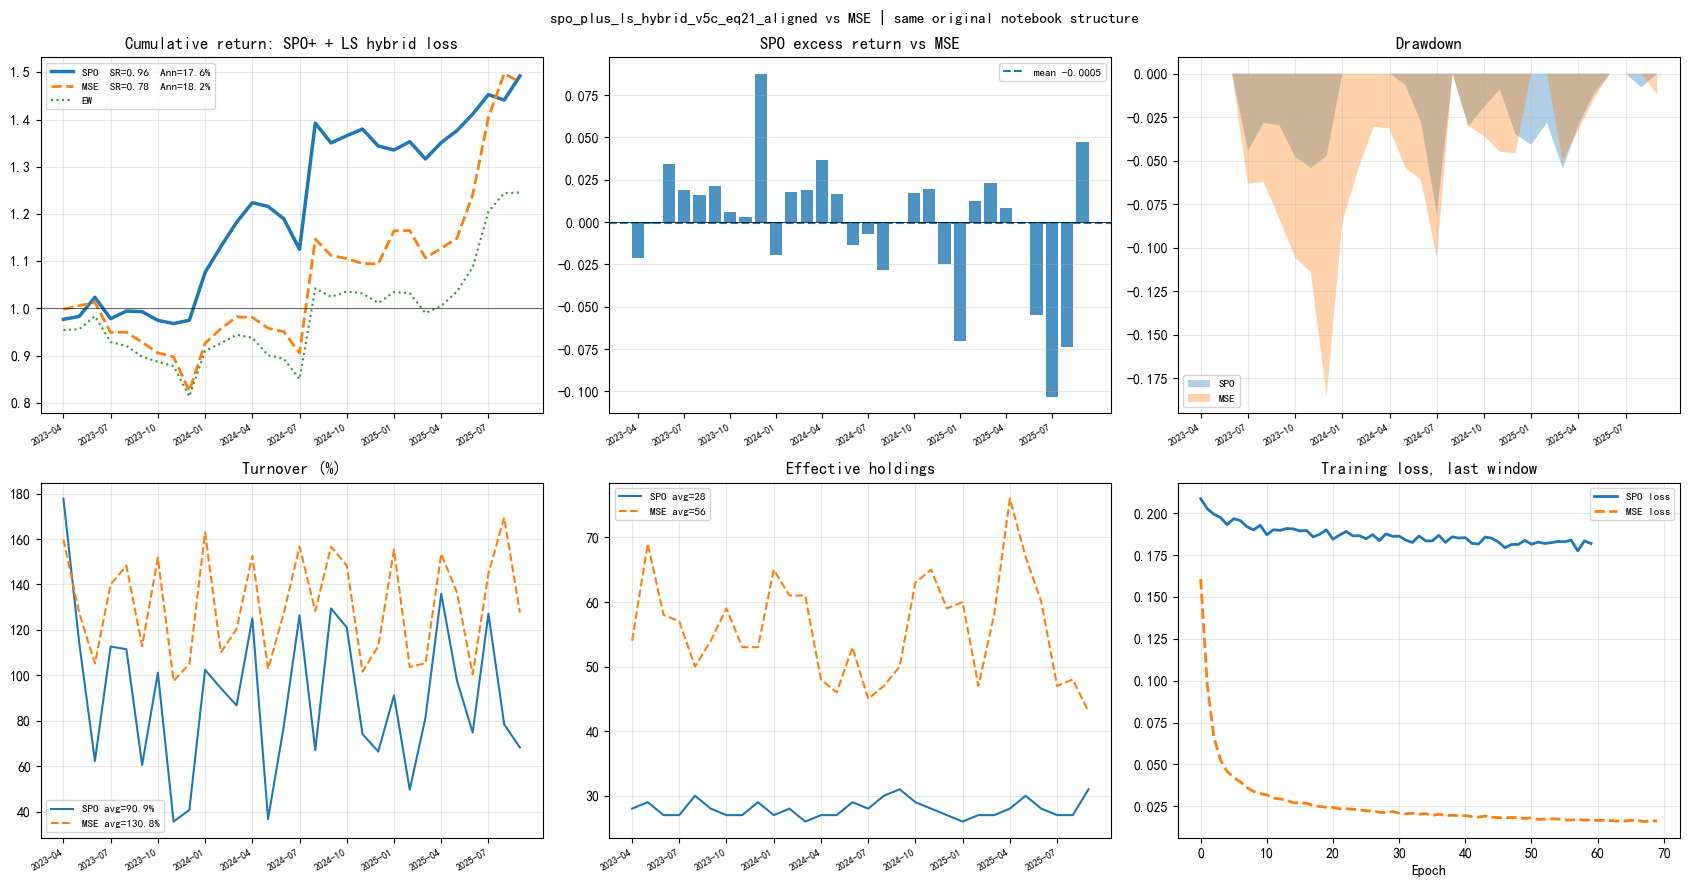

In [12]:
N_TEST = len(r_spo)
x = np.arange(N_TEST)
dlabels = [pd.Timestamp(d).strftime('%Y-%m') for d in res_spo['dates']]
step = max(1, N_TEST // 8)

cum_spo = np.cumprod(1 + r_spo)
cum_mse = np.cumprod(1 + r_mse)
cum_bch = np.cumprod(1 + r_bench)

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

ax = axes[0, 0]
ax.plot(cum_spo, lw=2.5, label=f"SPO  SR={m_spo['Sharpe']:.2f}  Ann={m_spo['Ann_Ret']:.1%}")
ax.plot(cum_mse, lw=2.0, ls='--', label=f"MSE  SR={m_mse['Sharpe']:.2f}  Ann={m_mse['Ann_Ret']:.1%}")
ax.plot(cum_bch, lw=1.5, ls=':', label='EW')
ax.axhline(1, color='k', lw=0.4)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title(f'Cumulative return: {SPO_LOSS_LABEL}')
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[0, 1]
excess = r_spo - r_mse
ax.bar(x, excess, alpha=0.8)
ax.axhline(excess.mean(), ls='--', lw=1.5, label=f'mean {excess.mean():.4f}')
ax.axhline(0, color='k', lw=0.5)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
ax.set_title('SPO excess return vs MSE')
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

def dd_s(c):
    return (c / np.maximum.accumulate(c)) - 1

ax = axes[0, 2]
ax.fill_between(x, 0, dd_s(cum_spo), alpha=0.35, label='SPO')
ax.fill_between(x, 0, dd_s(cum_mse), alpha=0.35, label='MSE')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title('Drawdown')
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[1, 0]
to_spo = calc_turnover(res_spo['weights'])
to_mse = calc_turnover(res_mse['weights'])
ax.plot(to_spo * 100, lw=1.5, label=f'SPO avg={to_spo.mean():.1%}')
ax.plot(to_mse * 100, lw=1.5, ls='--', label=f'MSE avg={to_mse.mean():.1%}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title('Turnover (%)')
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[1, 1]
eff_spo = [(w > 0.001).sum() for w in res_spo['weights']]
eff_mse = [(w > 0.001).sum() for w in res_mse['weights']]
ax.plot(eff_spo, lw=1.5, label=f'SPO avg={np.mean(eff_spo):.0f}')
ax.plot(eff_mse, lw=1.5, ls='--', label=f'MSE avg={np.mean(eff_mse):.0f}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title('Effective holdings')
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[1, 2]
if res_spo['loss_curves']:
    ax.plot(res_spo['loss_curves'][-1], lw=2, label='SPO loss')
if res_mse['loss_curves']:
    ax.plot(res_mse['loss_curves'][-1], lw=2, ls='--', label='MSE loss')
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_xlabel('Epoch')
ax.set_title('Training loss, last window')

plt.suptitle(f'{SPO_RUN_NAME} vs MSE | same original notebook structure', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
